In [1]:
!pip install missingno

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_absolute_error, r2_score, calinski_harabasz_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.ensemble import RandomForestRegressor


FIG_DIR = 'report/figures'
OUTPUT_DIR = 'outputs'
DATA_DIR = 'data'
LA_PREFIXES = ('E06', 'E07', 'E08', 'E09', 'W06')

for d in [FIG_DIR, OUTPUT_DIR]:
    if not os.path.exists(d):
        os.makedirs(d)

## Data load

In [3]:
"""Loads and cleans 2011 Census datasets."""
df_tenure = pd.read_excel(os.path.join(DATA_DIR, 'KS402EW-2011.xls'), sheet_name='KS402EW_Percentages', skiprows=10)
df_occ = pd.read_excel(os.path.join(DATA_DIR, 'QS408EW-2011.xls'), sheet_name='QS408EW_Numbers', skiprows=10)
df_acc = pd.read_excel(os.path.join(DATA_DIR, 'QS401EW-2011.xls'), sheet_name='QS401EW_Numbers', skiprows=10)

mask = df_tenure['Area code'].str.startswith(LA_PREFIXES, na=False)
df_2011 = df_tenure[mask].copy()
df_2011 = df_2011.rename(columns={'Area code': 'geo_code'})

df_2011 = df_2011.drop_duplicates(subset='geo_code').reset_index(drop=True)
df_2011['geo_name'] = df_2011['Area name'].fillna(df_2011['Unnamed: 3']).fillna(df_2011['Unnamed: 2']).astype(str).str.strip()

df_2011['owned_pct'] = df_2011[['Owned: Owned outright', 'Owned: Owned with a mortgage or loan']].sum(axis=1)
df_2011['private_rent_pct'] = df_2011[['Private rented: Private landlord or letting agency', 'Private rented: Other']].sum(axis=1)
df_2011['social_rent_pct'] = df_2011[['Social rented: Rented from council (Local Authority)', 'Social rented: Other']].sum(axis=1)

df_occ = df_occ.rename(columns={'Area code': 'geo_code'}).drop_duplicates(subset='geo_code')
df_2011 = pd.merge(df_2011, df_occ[['geo_code', 'Occupancy rating (rooms) of -1', 'Occupancy rating (rooms) of -2 or less', 'All categories: Occupancy rating (rooms) ']], on='geo_code').reset_index(drop=True)
df_2011['overcrowd_pct'] = (df_2011[['Occupancy rating (rooms) of -1', 'Occupancy rating (rooms) of -2 or less']].sum(axis=1) / df_2011['All categories: Occupancy rating (rooms) ']) * 100

shared_cols = ['Shared dwelling']
flat_cols = ['Unshared dwelling: Flat, maisonette or apartment: Purpose-built block of flats or tenement', 'Unshared dwelling: Flat, maisonette or apartment: Part of a converted or shared house (including bed-sits)', 'Unshared dwelling: Flat, maisonette or apartment: In commercial building']
df_acc = df_acc.rename(columns={'Area code': 'geo_code'}).drop_duplicates(subset='geo_code')
df_2011 = pd.merge(df_2011, df_acc[['geo_code', 'All categories: Accommodation type'] + flat_cols + shared_cols], on='geo_code').reset_index(drop=True)
df_2011['flat_pct'] = (df_2011[flat_cols].sum(axis=1) / df_2011['All categories: Accommodation type']) * 100
shared_col_11 = 'Unshared dwelling: Flat, maisonette or apartment: Part of a converted or shared house (including bed-sits)'
df_2011['shared_pct'] = (df_acc.set_index('geo_code').loc[df_2011['geo_code'], shared_col_11].values / df_2011['All categories: Accommodation type']) * 100

df_2011 = df_2011[['geo_code', 'geo_name', 'owned_pct', 'private_rent_pct', 'social_rent_pct', 'overcrowd_pct', 'flat_pct', 'shared_pct']]

display(df_2011.head())

,geo_code,geo_name,owned_pct,private_rent_pct,social_rent_pct,overcrowd_pct,flat_pct,shared_pct
0,E06000047,County Durham UA,65.8,12.6,20.1,3.62685,3.585935,0.422756
1,E06000005,Darlington UA,64.9,18.2,15.5,4.551103,8.004918,1.02967
2,E06000001,Hartlepool UA,59.8,14.8,23.5,4.313202,7.358575,0.492914
3,E06000002,Middlesbrough UA,57.2,16.6,23.9,6.990892,7.849085,0.760157
4,E06000048,Northumberland UA,65.9,13.3,18.7,3.61211,6.877855,1.059593


In [4]:
"""Loads and cleans 2021 Census datasets."""
df_tenure = pd.read_csv(os.path.join(DATA_DIR, 'census2021-ts054-ltla.csv'))
df_occ = pd.read_csv(os.path.join(DATA_DIR, 'census2021-ts053-ltla.csv'))
df_acc = pd.read_csv(os.path.join(DATA_DIR, 'census2021-ts044-ltla.csv'))

# Filtering and Feature Engineering
df_2021 = df_tenure[df_tenure['geography code'].str.startswith(LA_PREFIXES, na=False)].copy()
df_2021 = df_2021.rename(columns={'geography code': 'geo_code', 'geography': 'geo_name'})

# Clean up geo_name (remove redundant descriptors if any)
df_2021 = df_2021.drop_duplicates(subset='geo_code').reset_index(drop=True)
df_2021['geo_name'] = df_2021['geo_name'].str.strip()

df_2021['owned_pct'] = (df_2021['Tenure of household: Owned'] / df_2021['Tenure of household: Total: All households']) * 100
df_2021['private_rent_pct'] = (df_2021['Tenure of household: Private rented'] / df_2021['Tenure of household: Total: All households']) * 100
df_2021['social_rent_pct'] = (df_2021['Tenure of household: Social rented'] / df_2021['Tenure of household: Total: All households']) * 100

df_occ = df_occ.rename(columns={'geography code': 'geo_code'}).drop_duplicates(subset='geo_code')
df_2021 = pd.merge(df_2021, df_occ[['geo_code', 'Occupancy rating for rooms: Occupancy rating of rooms: -1', 'Occupancy rating for rooms: Occupancy rating of rooms: -2 or less', 'Occupancy rating for rooms: Total: All households']], on='geo_code').reset_index(drop=True)
df_2021['overcrowd_pct'] = ((df_2021['Occupancy rating for rooms: Occupancy rating of rooms: -1'] + df_2021['Occupancy rating for rooms: Occupancy rating of rooms: -2 or less']) / df_2021['Occupancy rating for rooms: Total: All households']) * 100

flat_cols = [c for c in df_acc.columns if any(k in c.lower() for k in ['flat', 'converted', 'commercial'])]
shared_col = 'Accommodation type: Part of a converted or shared house, including bedsits'
selected_acc_cols = list(dict.fromkeys(['geo_code', 'Accommodation type: Total: All households', shared_col] + flat_cols))
df_acc = df_acc.rename(columns={'geography code': 'geo_code'}).drop_duplicates(subset='geo_code')
df_2021 = pd.merge(df_2021, df_acc[selected_acc_cols], on='geo_code').reset_index(drop=True)
df_2021['flat_pct'] = (df_2021[flat_cols].sum(axis=1) / df_2021['Accommodation type: Total: All households']) * 100
df_2021['shared_pct'] = (df_2021[shared_col] / df_2021['Accommodation type: Total: All households']) * 100

df_2021 = df_2021[['geo_code', 'geo_name', 'owned_pct', 'private_rent_pct', 'social_rent_pct', 'overcrowd_pct', 'flat_pct', 'shared_pct']]

display(df_2021.head())

,geo_code,geo_name,owned_pct,private_rent_pct,social_rent_pct,overcrowd_pct,flat_pct,shared_pct
0,E06000001,Hartlepool,58.232549,17.576779,23.440592,3.163861,11.543536,0.767126
1,E06000002,Middlesbrough,54.985481,21.035427,23.240687,4.209950,12.560154,1.073645
2,E06000003,Redcar and Cleveland,64.658165,15.814919,18.899056,2.477368,8.916722,1.283320
3,E06000004,Stockton-on-Tees,66.158842,16.962367,16.324801,2.926323,9.164717,0.863222
4,E06000005,Darlington,62.753757,20.603087,16.213840,2.563421,13.135732,1.518806


In [5]:
df_merged = pd.merge(df_2011, df_2021, on='geo_code', how='right', suffixes=('_11', '_21')).reset_index(drop=True)

df_merged['geo_name'] = df_merged['geo_name_21'].fillna(df_merged['geo_name_11'])
df_merged['geo_name_11'] = df_merged['geo_name']
df_merged['geo_name_21'] = df_merged['geo_name']

display(df_merged.head())

print(df_merged.shape)

,geo_code,geo_name_11,owned_pct_11,private_rent_pct_11,social_rent_pct_11,overcrowd_pct_11,flat_pct_11,shared_pct_11,geo_name_21,owned_pct_21,private_rent_pct_21,social_rent_pct_21,overcrowd_pct_21,flat_pct_21,shared_pct_21,geo_name
0,E06000001,Hartlepool,59.8,14.8,23.5,4.313202,7.358575,0.492914,Hartlepool,58.232549,17.576779,23.440592,3.163861,11.543536,0.767126,Hartlepool
1,E06000002,Middlesbrough,57.2,16.6,23.9,6.990892,7.849085,0.760157,Middlesbrough,54.985481,21.035427,23.240687,4.209950,12.560154,1.073645,Middlesbrough
2,E06000003,Redcar and Cleveland,66.6,12.4,19.4,3.846993,5.519342,0.98261,Redcar and Cleveland,64.658165,15.814919,18.899056,2.477368,8.916722,1.283320,Redcar and Cleveland
3,E06000004,Stockton-on-Tees,68.5,13.1,17.2,4.522543,6.395012,0.558632,Stockton-on-Tees,66.158842,16.962367,16.324801,2.926323,9.164717,0.863222,Stockton-on-Tees
4,E06000005,Darlington,64.9,18.2,15.5,4.551103,8.004918,1.02967,Darlington,62.753757,20.603087,16.213840,2.563421,13.135732,1.518806,Darlington


(331, 16)


## Missing Value

In [6]:
missing_count = df_merged.isna().sum().sort_values(ascending=False)
display(missing_count)

owned_pct_11           14
private_rent_pct_11    14
social_rent_pct_11     14
overcrowd_pct_11       14
flat_pct_11            14
shared_pct_11          14
geo_code                0
geo_name_11             0
geo_name_21             0
owned_pct_21            0
private_rent_pct_21     0
social_rent_pct_21      0
overcrowd_pct_21        0
flat_pct_21             0
shared_pct_21           0
geo_name                0
dtype: int64

<Axes: >

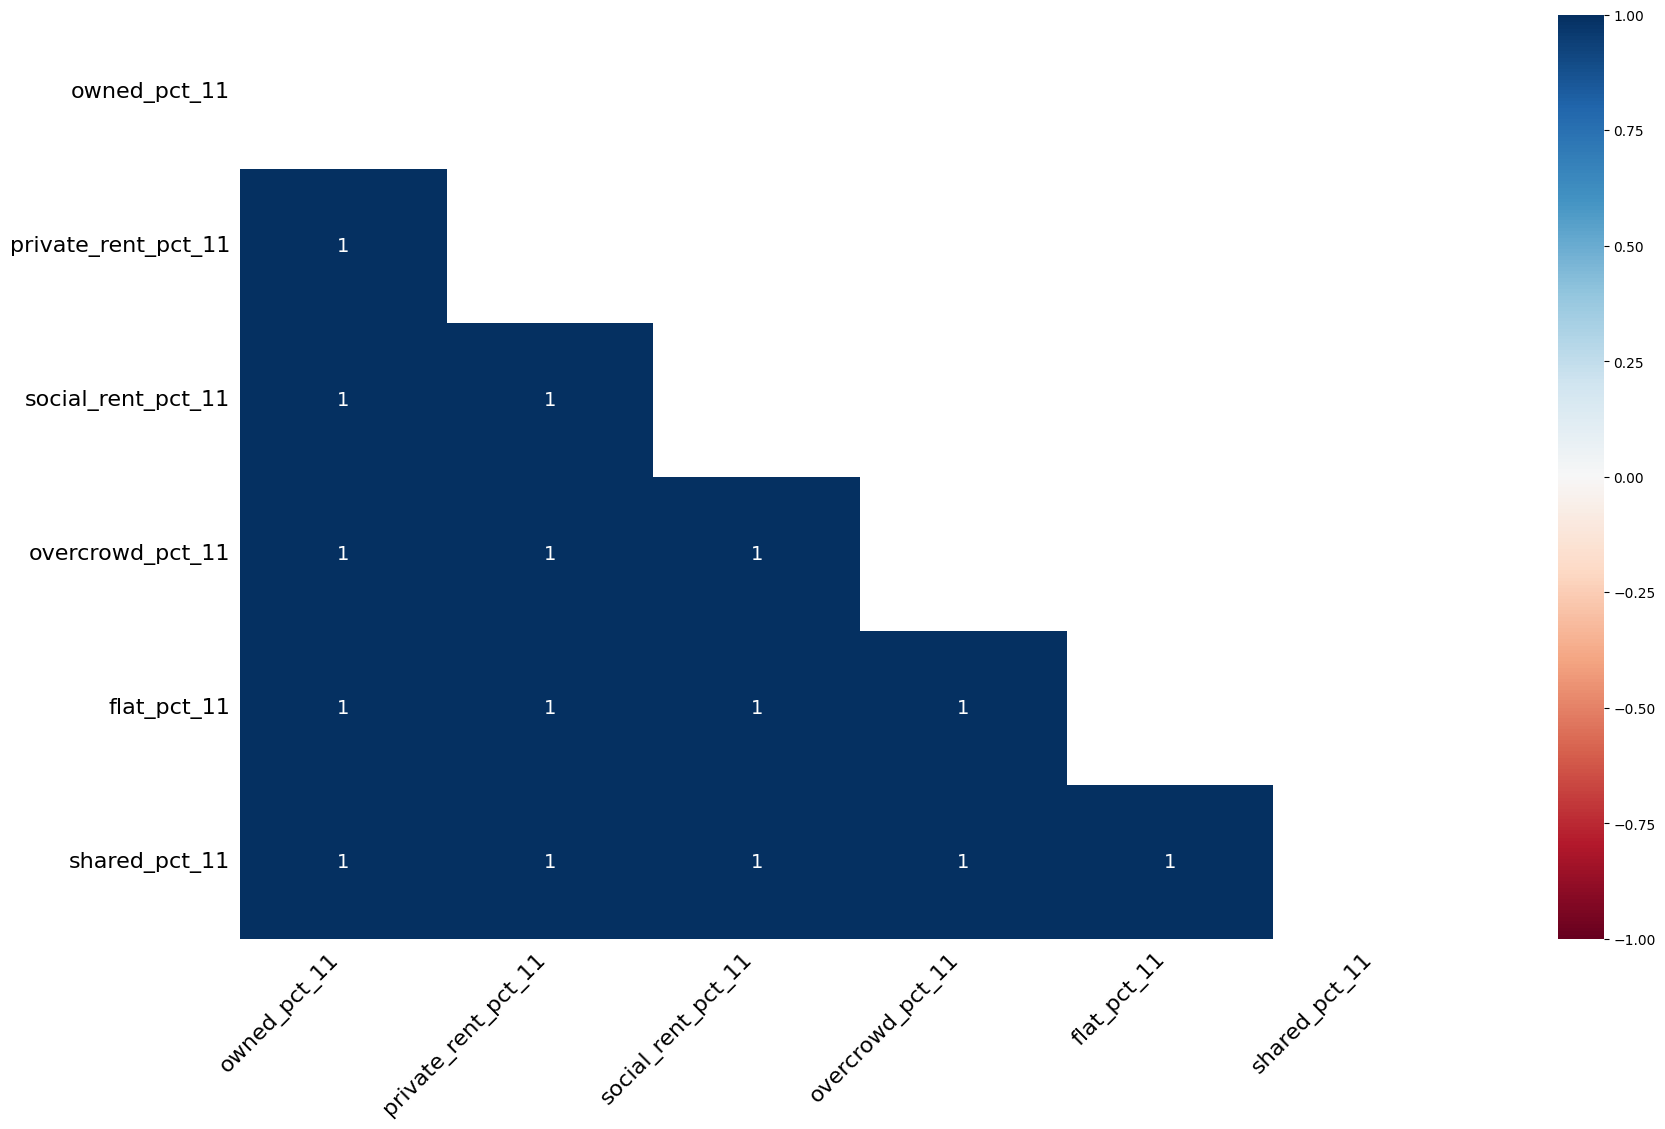

In [7]:
import missingno as msno

msno.heatmap(df_merged)

**Finding**: Data shows a cluster-based missing pattern. Variables within the same year always drop out together, with a correlation of 1.0. In contrast, data from 2011 and 2021 are almost no correlation, with a value of -0.1.

### Fill Missing

In [8]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np


mask = df_merged['overcrowd_pct_21'].isna()
df_merged['is_imputed'] = mask

features_11 = ['owned_pct_11', 'private_rent_pct_11', 'social_rent_pct_11', 'overcrowd_pct_11', 'flat_pct_11', 'shared_pct_11']
targets_21 = ['owned_pct_21', 'private_rent_pct_21', 'social_rent_pct_21', 'overcrowd_pct_21', 'flat_pct_21', 'shared_pct_21']
all_features = features_11 + targets_21

df_gt = df_merged[~mask].copy()
if len(df_gt) > 50:
    np.random.seed(42)
    test_indices = df_gt.sample(frac=0.15).index
    y_true = df_gt.loc[test_indices, 'overcrowd_pct_21'].values

    df_test = df_gt.copy()
    df_test.loc[test_indices, targets_21] = np.nan

    # A. Baseline: Mean Imputation
    y_mean = np.full(len(y_true), df_gt['overcrowd_pct_21'].mean())

    # B. Bayesian Ridge Imputation
    imputer_bayesian = IterativeImputer(estimator=BayesianRidge(), random_state=42)
    y_bayesian = imputer_bayesian.fit_transform(df_test[all_features])[df_gt.index.get_indexer(test_indices), 9]

    print(f"[BENCHMARK] Imputation Error Analysis:")
    print(f" - Mean Baseline:  MAE={mean_absolute_error(y_true, y_mean):.4f} | R2={r2_score(y_true, y_mean):.4f}")
    print(f" - Bayesian Ridge: MAE={mean_absolute_error(y_true, y_bayesian):.4f} | R2={r2_score(y_true, y_bayesian):.4f}")

[BENCHMARK] Imputation Error Analysis:
 - Mean Baseline:  MAE=2.7045 | R2=-0.0941
 - Bayesian Ridge: MAE=0.9800 | R2=0.8476


/opt/homebrew/Caskroom/miniconda/base/envs/pynb/lib/python3.14/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [9]:
final_imputer = IterativeImputer(estimator=BayesianRidge(), max_iter=10, random_state=42)
df_merged[all_features] = final_imputer.fit_transform(df_merged[all_features])

common_cols = ['geo_code', 'is_imputed']

df_11_final = df_merged[common_cols + ['geo_name_11'] + features_11].copy()
df_11_final.columns = common_cols + ['geo_name', 'owned_pct', 'private_rent_pct', 'social_rent_pct', 'overcrowd_pct', 'flat_pct', 'shared_pct']
df_11_final['Year'] = 2011

df_21_final = df_merged[common_cols + ['geo_name_21'] + targets_21].copy()
df_21_final.columns = common_cols + ['geo_name', 'owned_pct', 'private_rent_pct', 'social_rent_pct', 'overcrowd_pct', 'flat_pct', 'shared_pct']
df_21_final['Year'] = 2021

df_final = pd.concat([df_11_final, df_21_final], axis=0).reset_index(drop=True)
display(df_final.head())

/opt/homebrew/Caskroom/miniconda/base/envs/pynb/lib/python3.14/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,geo_code,is_imputed,geo_name,owned_pct,private_rent_pct,social_rent_pct,overcrowd_pct,flat_pct,shared_pct,Year
0,E06000001,False,Hartlepool,59.8,14.8,23.5,4.313202,7.358575,0.492914,2011
1,E06000002,False,Middlesbrough,57.2,16.6,23.9,6.990892,7.849085,0.760157,2011
2,E06000003,False,Redcar and Cleveland,66.6,12.4,19.4,3.846993,5.519342,0.982610,2011
3,E06000004,False,Stockton-on-Tees,68.5,13.1,17.2,4.522543,6.395012,0.558632,2011
4,E06000005,False,Darlington,64.9,18.2,15.5,4.551103,8.004918,1.029670,2011


## EDA

📊 Phase 1: Running Exploratory Data Analysis (EDA)...


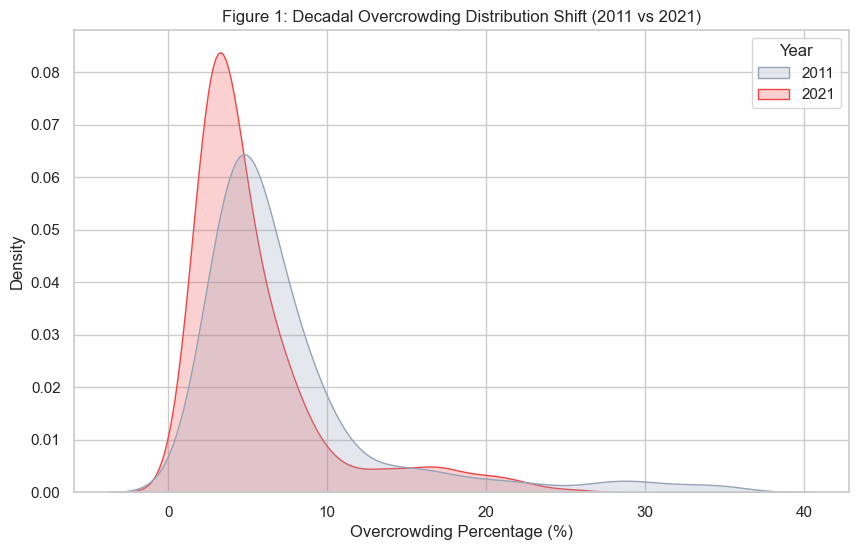

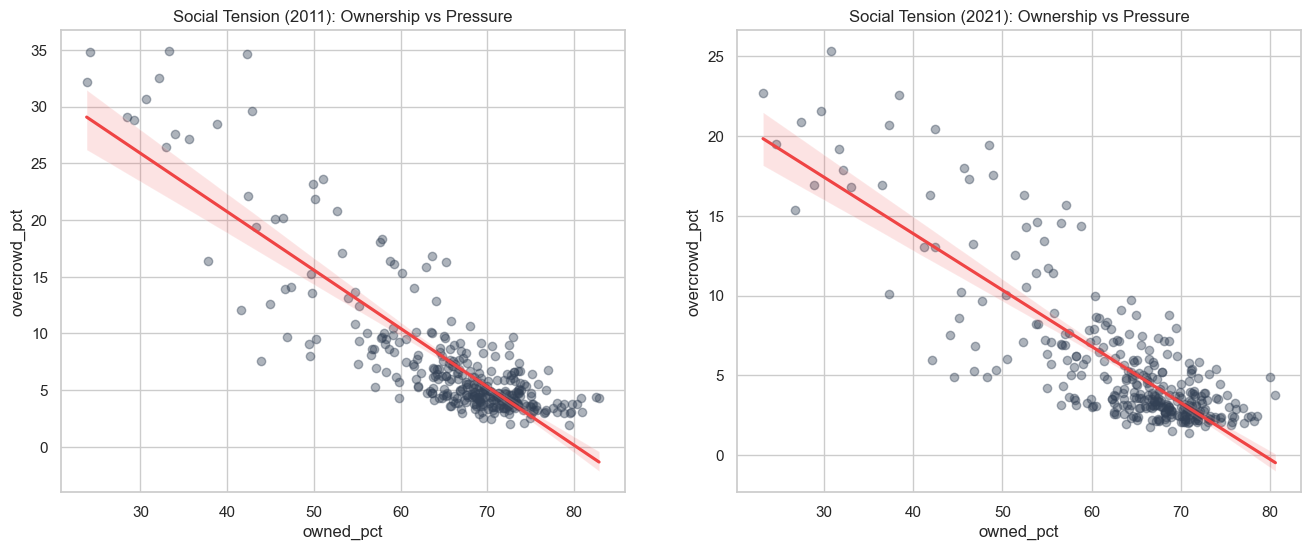

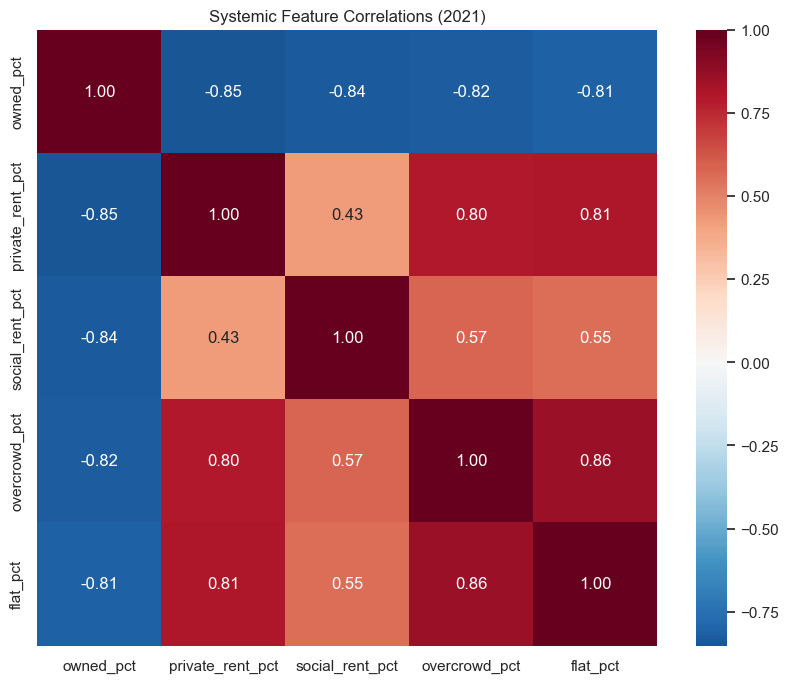

In [10]:
print("📊 Phase 1: Running Exploratory Data Analysis (EDA)...")
sns.set_theme(style="whitegrid")

# 1. Decadal Distribution Shift (KDE)
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_final, x="overcrowd_pct", hue="Year", fill=True, palette=['#94a3b8', '#ef4444'])
plt.title("Figure 1: Decadal Overcrowding Distribution Shift (2011 vs 2021)")
plt.xlabel("Overcrowding Percentage (%)")
plt.savefig(os.path.join(FIG_DIR, 'eda_overcrowding_shift.png'), dpi=300)
plt.show()

# 2. Social Tension: Ownership vs Pressure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
for i, year in enumerate([2011, 2021]):
    subset = df_final[df_final['Year'] == year]
    sns.regplot(data=subset, x="owned_pct", y="overcrowd_pct", ax=[ax1, ax2][i],
                scatter_kws={'alpha':0.4, 'color':'#334155'}, line_kws={'color':'#ef4444'})
    [ax1, ax2][i].set_title(f"Social Tension ({year}): Ownership vs Pressure")
plt.savefig(os.path.join(FIG_DIR, 'eda_social_tension.png'), dpi=300)
plt.show()

# 3. Correlation Matrix
plt.figure(figsize=(10, 8))
corr = df_final[df_final['Year']==2021][['owned_pct', 'private_rent_pct', 'social_rent_pct', 'overcrowd_pct', 'flat_pct']].corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title("Systemic Feature Correlations (2021)")
plt.savefig(os.path.join(FIG_DIR, 'eda_correlation_matrix.png'), dpi=300)
plt.show()

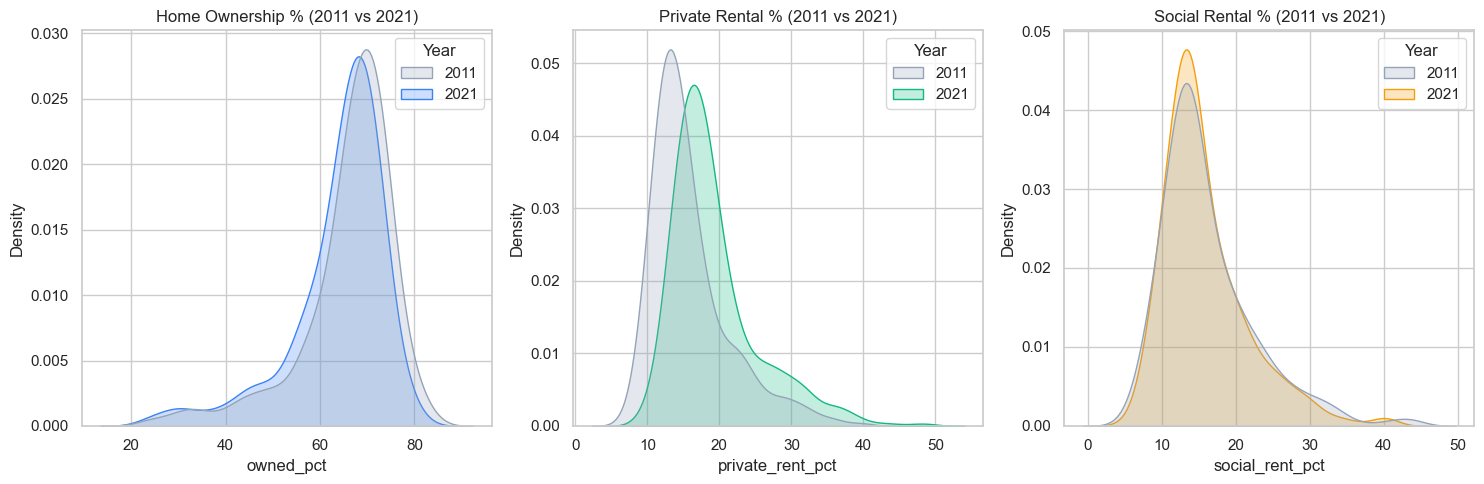

In [11]:
# 4. Decadal Shifts in Tenure Types (KDE)
plt.figure(figsize=(15, 5))

# Ownership KDE
plt.subplot(1, 3, 1)
sns.kdeplot(data=df_final, x="owned_pct", hue="Year", fill=True, palette=['#94a3b8', '#3b82f6'])
plt.title("Home Ownership % (2011 vs 2021)")

# Private Rental KDE
plt.subplot(1, 3, 2)
sns.kdeplot(data=df_final, x="private_rent_pct", hue="Year", fill=True, palette=['#94a3b8', '#10b981'])
plt.title("Private Rental % (2011 vs 2021)")

# Social Rental KDE
plt.subplot(1, 3, 3)
sns.kdeplot(data=df_final, x="social_rent_pct", hue="Year", fill=True, palette=['#94a3b8', '#f59e0b'])
plt.title("Social Rental % (2011 vs 2021)")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_tenure_shifts.png'), dpi=300)
plt.show()

### **Core EDA Findings**

1. **Decadal Distribution Shift**: Figure 1 shows that from 2011 to 2021, the distribution of overcrowding (`overcrowd_pct`) significantly shifted to the right and the peak widened. This indicates that systemic residential pressure has increased across most Local Authorities over the past decade, with extreme overcrowding becoming more prevalent.

2. **Social Tension Analysis**: Regression analysis reveals a persistent and significant negative correlation between `owned_pct` (home ownership) and `overcrowd_pct`. Areas with lower home ownership typically face higher overcrowding pressures. This structural contradiction appears even more strained in 2021 compared to 2011.

3. **Evolution of Tenure Types**: The KDE plots illustrate a significant rise in the private rental sector (`private_rent_pct`) over the decade, while home ownership has shrunk in many regions. This reflects a structural transition in the housing market from 'owner-led' to 'rental-dependent'.

4. **Systemic Correlations**: The 2021 correlation matrix reveals that overcrowding is highly positively correlated with high-density housing (`flat_pct`, coefficient 0.86) and the private rental market. This confirms that the current housing crisis is deeply tied to urban high-density development and the expansion of the rental market.

## KMeans

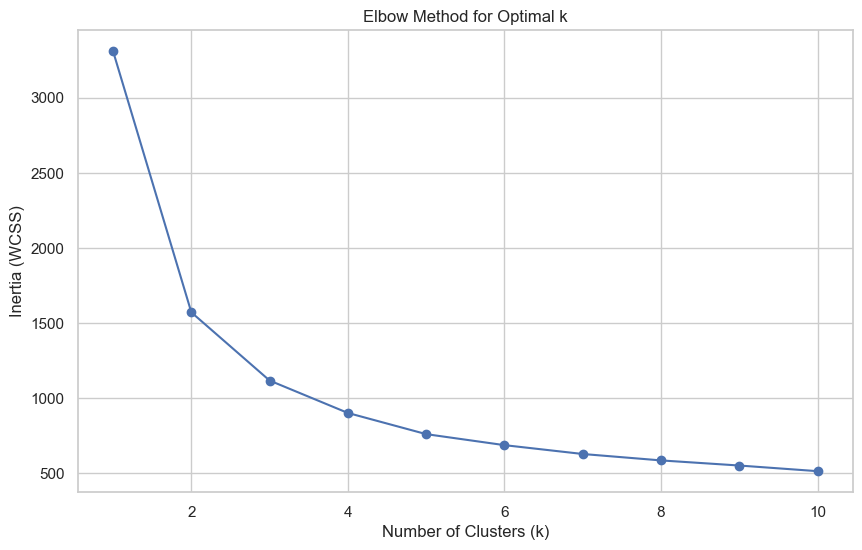

In [12]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


features = ['owned_pct', 'private_rent_pct', 'social_rent_pct', 'overcrowd_pct', 'flat_pct']

scaler = StandardScaler()
X = scaler.fit_transform(df_final[features])

inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.savefig(os.path.join(FIG_DIR, 'kmeans_elbow.png'), dpi=300)
plt.show()

In [13]:

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import BayesianRidge


kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_final['Archetype_ID'] = kmeans.fit_predict(X)

df_final.groupby('Archetype_ID')[features].mean()

,owned_pct,private_rent_pct,social_rent_pct,overcrowd_pct,flat_pct
Archetype_ID,,,,,
0,62.290674,15.199218,21.043871,5.736427,12.334260
1,33.606648,33.284442,30.565267,23.795194,70.074657
2,70.584844,15.292679,12.560194,4.201678,11.140270
3,53.972846,25.634090,18.689510,11.513651,28.479601


### **Housing Archetype Definitions**

Based on the clustering results, we can define four distinct socio-economic housing profiles:

1. **Established Suburbanites (Cluster 0)**: This group has the highest home ownership rates at 70%. It also experiences low overcrowding and low levels of high-density housing. These areas are stable and residential.
2. **Central Urban Stressed (Cluster 1)**: This is the most vulnerable group, with ownership at just 33%. It has high rates of social and private rentals and extreme overcrowding at 24%. This cluster mainly consists of high-density flats.
3. **Transitional Renters (Cluster 2)**: These areas have a significant private rental market at 26% and moderate overcrowding at 11%. They often serve as urban "stepping stone" neighborhoods.
4. **Social & Constrained (Cluster 3)**: This group relies heavily on social housing at 21%, even though ownership is relatively high. Overcrowding is low, but the available housing is less flexible compared to Cluster 0.

In [14]:
archetype_map = {
    0: 'Established Suburbanites',
    1: 'Central Urban Stressed',
    2: 'Transitional Renters',
    3: 'Social & Constrained'
}
df_final['Archetype'] = df_final['Archetype_ID'].map(archetype_map)


### PCA & t-SNE

In [15]:
pca = PCA(n_components=2)
pca_res = pca.fit_transform(X)
df_final['PC1'], df_final['PC2'] = pca_res[:, 0], pca_res[:, 1]

pca_loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=features)
output_path = os.path.join(OUTPUT_DIR, 'PCA_loadings.csv')
pca_loadings.to_csv(output_path, index=True)
display(pca_loadings)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_res = tsne.fit_transform(X)
df_final['TSNE1'], df_final['TSNE2'] = tsne_res[:, 0], tsne_res[:, 1]

,PC1,PC2
owned_pct,0.494738,-0.180883
private_rent_pct,-0.435183,-0.503100
social_rent_pct,-0.381913,0.788849
overcrowd_pct,-0.454264,-0.081032
flat_pct,-0.462209,-0.292100


In [16]:
explained_variance = pca.explained_variance_ratio_
total_explained = explained_variance.sum()

print(f"PC1 EVR: {explained_variance[0]:.2%}")
print(f"PC2 EVR: {explained_variance[1]:.2%}")
print(f"EVR : {total_explained:.2%}")

PC1 EVR: 76.89%
PC2 EVR: 13.91%
EVR : 90.80%


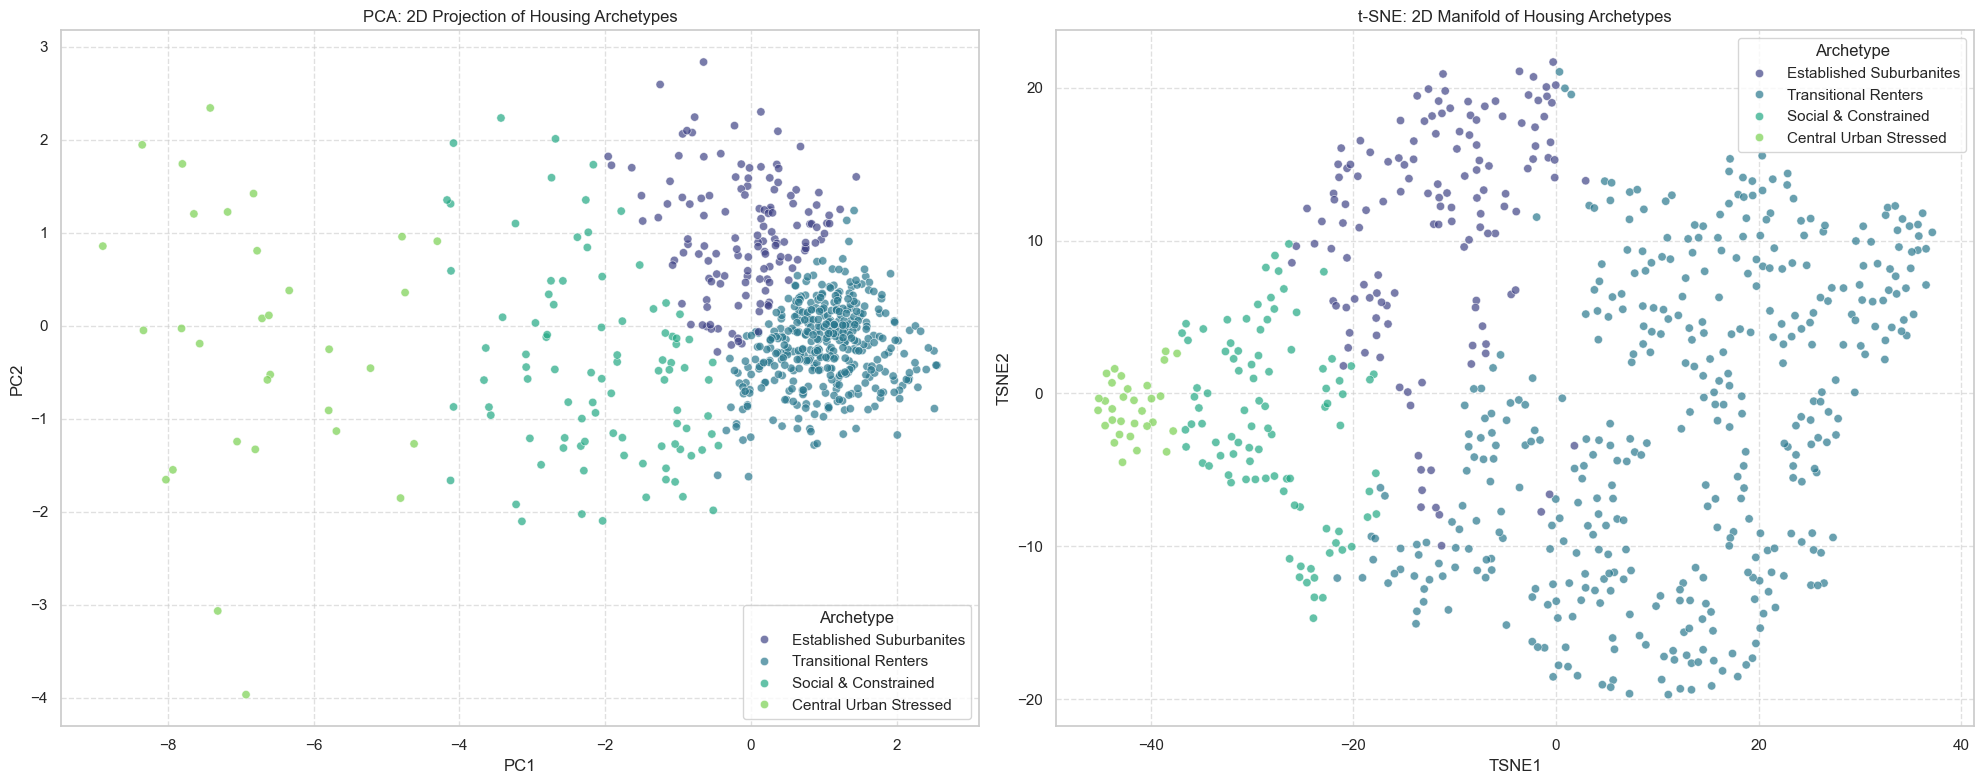

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# PCA Plot
sns.scatterplot(data=df_final, x='PC1', y='PC2', hue='Archetype', palette='viridis', alpha=0.7, ax=ax1)
ax1.set_title('PCA: 2D Projection of Housing Archetypes')
ax1.grid(True, linestyle='--', alpha=0.6)

# t-SNE Plot
sns.scatterplot(data=df_final, x='TSNE1', y='TSNE2', hue='Archetype', palette='viridis', alpha=0.7, ax=ax2)
ax2.set_title('t-SNE: 2D Manifold of Housing Archetypes')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pca_tsne_archetypes.png'), dpi=300)
plt.show()

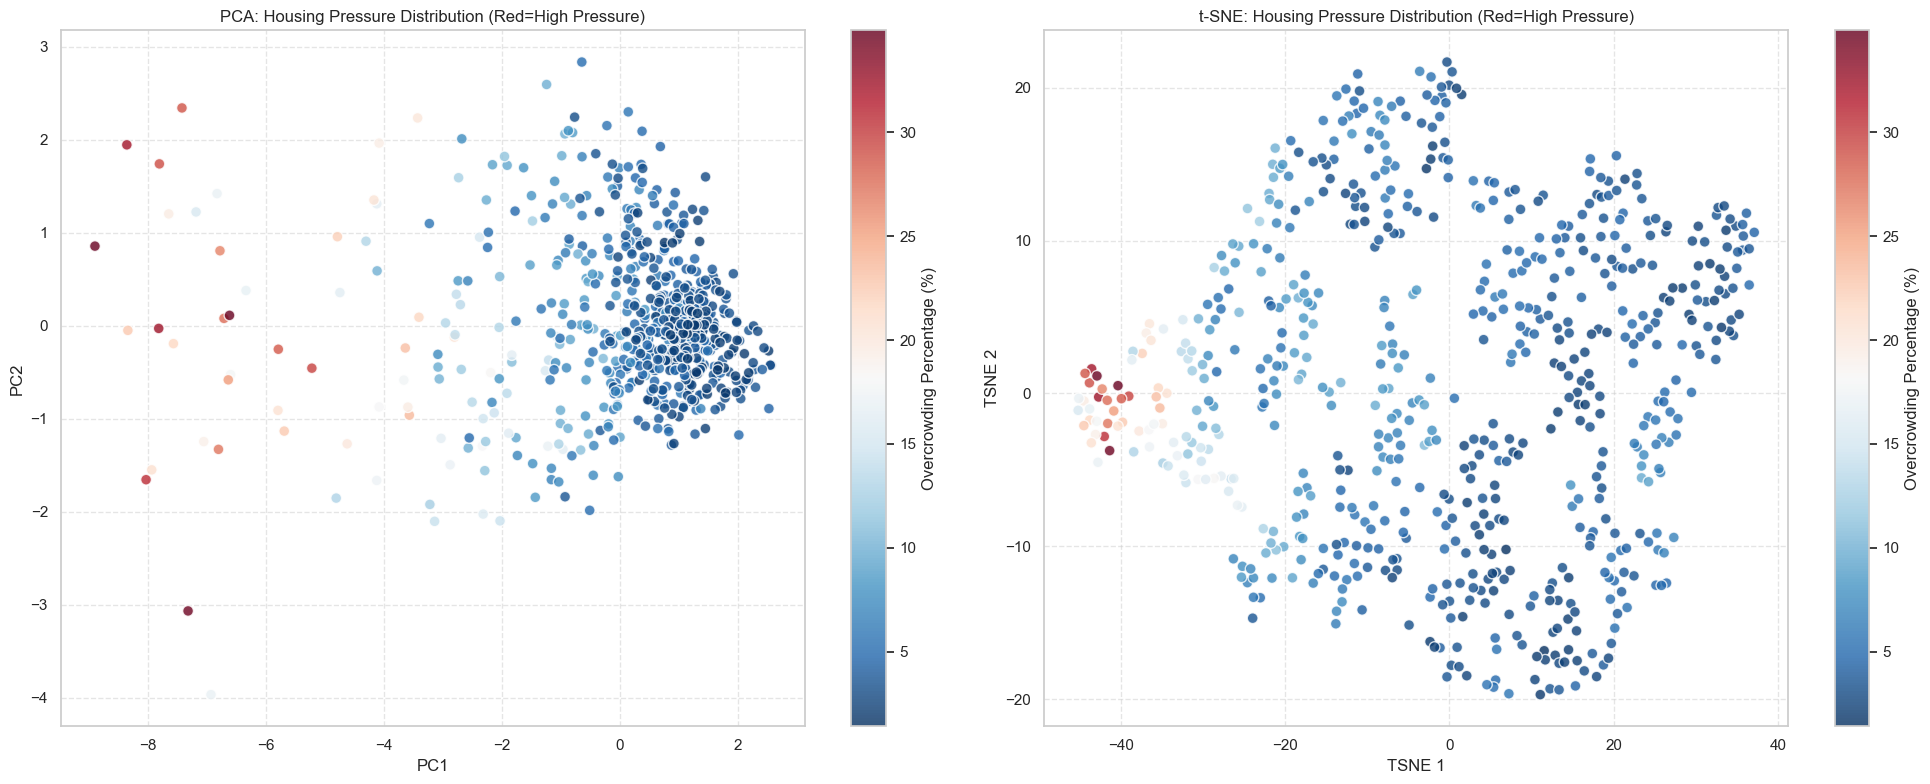

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# PCA Plot with Housing Pressure (Red=High, Blue=Low)
sc1 = ax1.scatter(df_final['PC1'], df_final['PC2'], c=df_final['overcrowd_pct'], cmap='RdBu_r', alpha=0.8, edgecolor='w', s=60)
plt.colorbar(sc1, ax=ax1, label='Overcrowding Percentage (%)')
ax1.set_title('PCA: Housing Pressure Distribution (Red=High Pressure)')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.grid(True, linestyle='--', alpha=0.5)

# t-SNE Plot with Housing Pressure (Red=High, Blue=Low)
sc2 = ax2.scatter(df_final['TSNE1'], df_final['TSNE2'], c=df_final['overcrowd_pct'], cmap='RdBu_r', alpha=0.8, edgecolor='w', s=60)
plt.colorbar(sc2, ax=ax2, label='Overcrowding Percentage (%)')
ax2.set_title('t-SNE: Housing Pressure Distribution (Red=High Pressure)')
ax2.set_xlabel('TSNE 1')
ax2.set_ylabel('TSNE 2')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pca_tsne_pressure_distribution.png'), dpi=300)
plt.show()

## Bayesian Prediction

In [19]:
model = BayesianRidge()
scaler = StandardScaler()


df_clean = df_final[df_final['is_imputed'] == False].copy()

df_11 = df_clean[df_clean['Year']==2011].sort_values('geo_code')
df_21 = df_clean[df_clean['Year']==2021].sort_values('geo_code')

common_codes = set(df_11['geo_code']) & set(df_21['geo_code'])
X_train = df_11[df_11['geo_code'].isin(common_codes)][features]
y_train = df_21[df_21['geo_code'].isin(common_codes)]['overcrowd_pct']

X_scaled_train = scaler.fit_transform(X_train)

model.fit(X_scaled_train, y_train)

df_21 = df_final[df_final['Year'] == 2021].copy()
X_2021 = df_21[features]
X_scaled_2021 = scaler.transform(X_2021)

y_proj, y_std = model.predict(X_scaled_2021, return_std=True)

df_21['proj_2031'] = y_proj
df_21['uncertainty'] = y_std * 2 # 95% interval approximation
df_21['proj_2031'] = df_21['proj_2031'].map(lambda x: 0 if x < 0 else x)


df_21.head()

,geo_code,is_imputed,geo_name,owned_pct,private_rent_pct,social_rent_pct,overcrowd_pct,flat_pct,shared_pct,Year,Archetype_ID,Archetype,PC1,PC2,TSNE1,TSNE2,proj_2031,uncertainty
331,E06000001,False,Hartlepool,58.232549,17.576779,23.440592,3.163861,11.543536,0.767126,2021,0,Established Suburbanites,-0.349390,1.225372,-15.332072,13.190939,1.386260,2.121850
332,E06000002,False,Middlesbrough,54.985481,21.035427,23.240687,4.209950,12.560154,1.073645,2021,0,Established Suburbanites,-0.864365,0.932522,-21.996674,6.045692,2.143048,2.134049
333,E06000003,False,Redcar and Cleveland,64.658165,15.814919,18.899056,2.477368,8.916722,1.283320,2021,0,Established Suburbanites,0.514043,0.732211,-10.294562,11.250321,1.360323,2.106204
334,E06000004,False,Stockton-on-Tees,66.158842,16.962367,16.324801,2.926323,9.164717,0.863222,2021,2,Transitional Renters,0.619712,0.264749,2.746344,-4.732183,1.870632,2.105346
335,E06000005,False,Darlington,62.753757,20.603087,16.213840,2.563421,13.135732,1.518806,2021,0,Established Suburbanites,0.105922,-0.065608,-12.336221,-5.023252,0.850787,2.135481


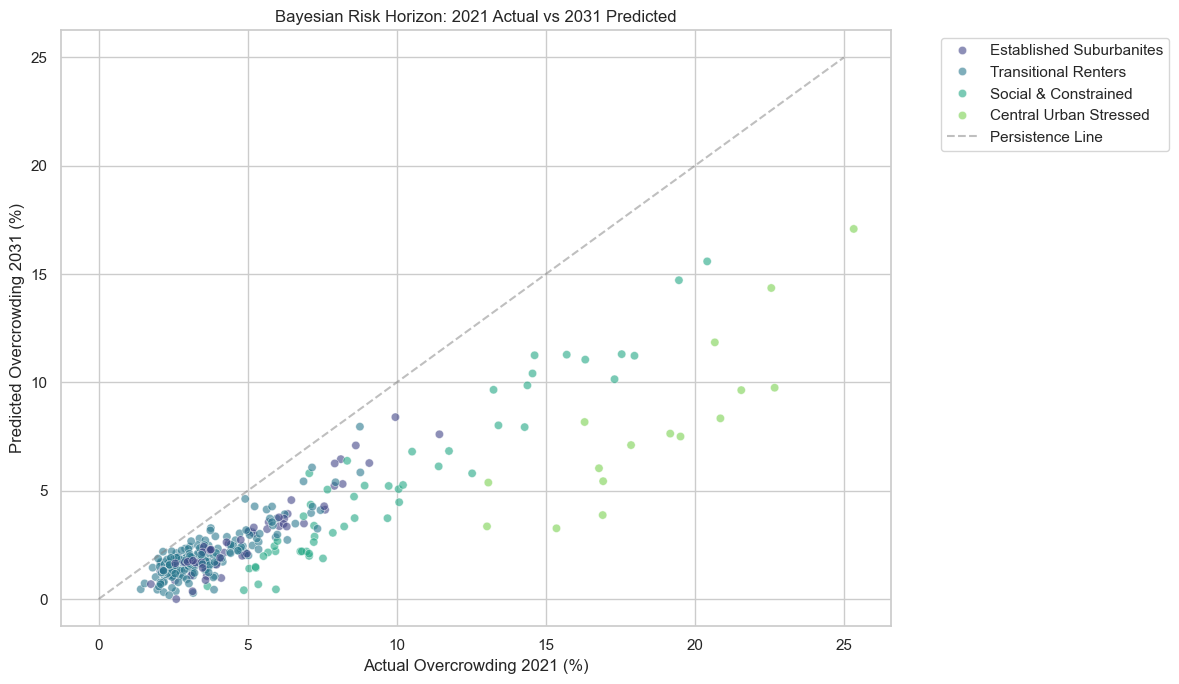

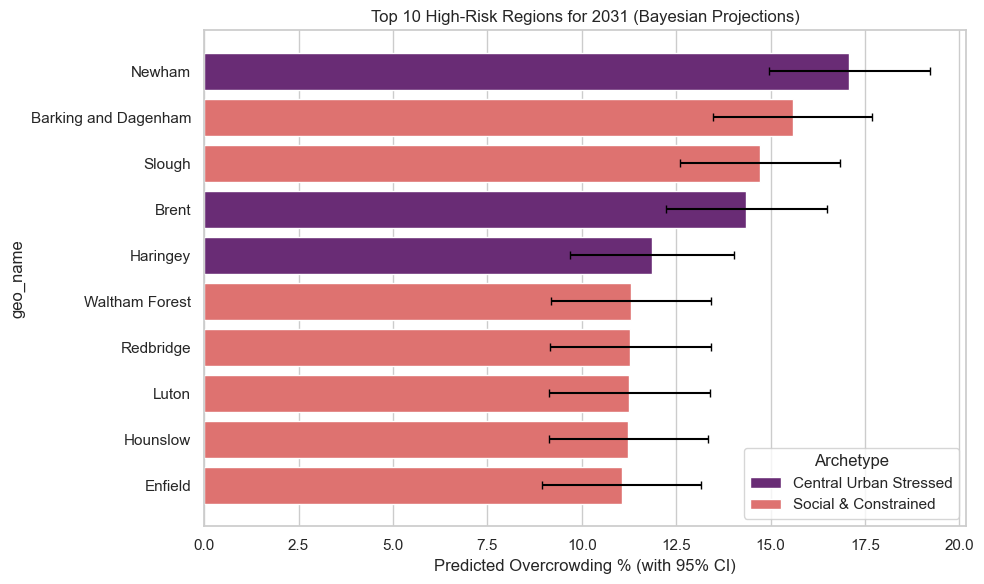

In [20]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_21, x='overcrowd_pct', y='proj_2031', hue='Archetype', alpha=0.6, palette='viridis')
plt.plot([0, 25], [0, 25], '--', color='grey', alpha=0.5, label="Persistence Line")
plt.title("Bayesian Risk Horizon: 2021 Actual vs 2031 Predicted")
plt.xlabel("Actual Overcrowding 2021 (%)")
plt.ylabel("Predicted Overcrowding 2031 (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'bayesian_risk_horizon.png'), dpi=300)
plt.show()

# 2. Top 10 High-Risk Regions
plt.figure(figsize=(10, 6))
top_10 = df_21.nlargest(10, 'proj_2031')
sns.barplot(data=top_10, x='proj_2031', y='geo_name', hue='Archetype', palette='magma')
plt.errorbar(top_10['proj_2031'], range(10), xerr=top_10['uncertainty'], fmt='none', c='black', capsize=3)
plt.title("Top 10 High-Risk Regions for 2031 (Bayesian Projections)")
plt.xlabel("Predicted Overcrowding % (with 95% CI)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'top_risk_regions.png'), dpi=300)
plt.show()

In [21]:
top_10['geo_name'].tolist()

['Newham',
 'Barking and Dagenham',
 'Slough',
 'Brent',
 'Haringey',
 'Waltham Forest',
 'Redbridge',
 'Luton',
 'Hounslow',
 'Enfield']

In [22]:
df_final = pd.merge(df_final, df_21[['geo_code', 'proj_2031', 'uncertainty']], on='geo_code', how='left')

# Calculate Manifold Drift Magnitude
drift_data = []
for code in df_final['geo_code'].unique():
    subset = df_final[df_final['geo_code'] == code].sort_values('Year')
    if len(subset) == 2:
        dist = np.linalg.norm(subset.iloc[1][['PC1', 'PC2']].values - subset.iloc[0][['PC1', 'PC2']].values)
        drift_data.append({'geo_code': code, 'Drift_Magnitude': dist})
df_final = pd.merge(df_final, pd.DataFrame(drift_data), on='geo_code', how='left')

# Mapping to Final Schema
rename_dict = {
    'geo_code': 'LA Code', 'geo_name': 'LA Name', 'owned_pct': 'Housing Ownership %',
    'private_rent_pct': 'Private Rental %', 'social_rent_pct': 'Social Rental %', 'overcrowd_pct': 'Overcrowding %', 'flat_pct': 'High-Density Housing %',
    'Drift_Magnitude': 'Decadal Drift Magnitude (Manifold)', 'proj_2031': 'Projected Overcrowding % (2031)',
    'uncertainty': 'Bayesian Uncertainty (95% CI)', 'Archetype': 'Housing Archetype (Cluster)'
}
df_export = df_final.rename(columns=rename_dict)
df_export['Upper Bound (2031)'] = (df_export['Projected Overcrowding % (2031)'] + (1.96*df_export['Bayesian Uncertainty (95% CI)'] / 2))
df_export['Lower Bound (2031)'] = (df_export['Projected Overcrowding % (2031)'] - (1.96*df_export['Bayesian Uncertainty (95% CI)'] / 2)).clip(lower=0)

output_path = os.path.join(OUTPUT_DIR, 'VISA_Submission_Data.csv')
df_export.to_csv(output_path, index=False)

df_export.head()

,LA Code,is_imputed,LA Name,Housing Ownership %,Private Rental %,Social Rental %,Overcrowding %,High-Density Housing %,shared_pct,Year,...,Housing Archetype (Cluster),PC1,PC2,TSNE1,TSNE2,Projected Overcrowding % (2031),Bayesian Uncertainty (95% CI),Decadal Drift Magnitude (Manifold),Upper Bound (2031),Lower Bound (2031)
0,E06000001,False,Hartlepool,59.8,14.8,23.5,4.313202,7.358575,0.492914,2011,...,Established Suburbanites,-0.043877,1.501831,-14.063041,15.310586,1.386260,2.121850,0.412029,3.465672,0.00000
1,E06000002,False,Middlesbrough,57.2,16.6,23.9,6.990892,7.849085,0.760157,2011,...,Established Suburbanites,-0.566907,1.399414,-17.060865,12.545563,2.143048,2.134049,0.553597,4.234416,0.05168
2,E06000003,False,Redcar and Cleveland,66.6,12.4,19.4,3.846993,5.519342,0.982610,2011,...,Established Suburbanites,0.813107,1.093751,-2.075224,17.408735,1.360323,2.106204,0.469202,3.424403,0.00000
3,E06000004,False,Stockton-on-Tees,68.5,13.1,17.2,4.522543,6.395012,0.558632,2011,...,Transitional Renters,0.908401,0.689324,4.806391,13.881278,1.870632,2.105346,0.513425,3.933870,0.00000
4,E06000005,False,Darlington,64.9,18.2,15.5,4.551103,8.004918,1.029670,2011,...,Transitional Renters,0.419422,0.075116,-0.404171,-8.632561,0.850787,2.135481,0.343636,2.943558,0.00000


In [23]:
len(list(set(df_export['LA Code'].tolist())))

331